In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso


In [5]:
# Read in the data
X_train, y_train = pd.read_csv("data/bitcoin_X_train.csv"), pd.read_csv("data/bitcoin_y_train.csv")
X_test, y_test = pd.read_csv("data/bitcoin_X_test.csv"), pd.read_csv("data/bitcoin_y_test.csv")


In [7]:
# Make sure data is what is expected
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (1815, 69) (1815, 1)
Test shape: (454, 69) (454, 1)


In [8]:
X_train.head()

,btc_total_bitcoins_lag_1,btc_total_bitcoins_lag_2,btc_total_bitcoins_lag_3,btc_blocks_size_lag_1,btc_blocks_size_lag_2,btc_blocks_size_lag_3,btc_avg_block_size_lag_1,btc_avg_block_size_lag_2,btc_avg_block_size_lag_3,btc_n_orphaned_blocks_lag_1,...,log_btc_transaction_fees_lag_3,log_btc_cost_per_transaction_lag_1,log_btc_cost_per_transaction_lag_2,log_btc_cost_per_transaction_lag_3,log_btc_estimated_transaction_volume_usd_lag_1,log_btc_estimated_transaction_volume_usd_lag_2,log_btc_estimated_transaction_volume_usd_lag_3,log_btc_output_volume_lag_1,log_btc_output_volume_lag_2,log_btc_output_volume_lag_3
0,7801700.0,7794850.0,7787350.0,576.0,574.0,572.0,0.015659,0.016900,0.017415,0.0,...,1.668640,1.583799,1.657270,1.589670,16.075356,16.260030,16.155721,15.028780,15.210318,15.357117
1,7809700.0,7801700.0,7794850.0,578.0,576.0,574.0,0.017047,0.015659,0.016900,0.0,...,1.627956,1.546385,1.583799,1.657270,15.523569,16.075356,16.260030,14.553978,15.028780,15.210318
2,7817650.0,7809700.0,7801700.0,580.0,578.0,576.0,0.018309,0.017047,0.015659,0.0,...,1.506040,1.493998,1.546385,1.583799,16.692823,15.523569,16.075356,15.812862,14.553978,15.028780
3,7825000.0,7817650.0,7809700.0,583.0,580.0,578.0,0.021511,0.018309,0.017047,0.0,...,1.529492,1.431102,1.493998,1.546385,16.611276,16.692823,15.523569,15.536750,15.812862,14.553978
4,7832700.0,7825000.0,7817650.0,585.0,583.0,580.0,0.017581,0.021511,0.018309,0.0,...,1.503938,1.634398,1.431102,1.493998,16.308141,16.611276,16.692823,15.373687,15.536750,15.812862


In [9]:
y_train.head()

,target
0,1.398717
1,1.406587
2,1.410987
3,1.395997
4,1.396245


## Correlations with target

/var/folders/vj/1sk13cl96_j6ll67wvk7b8mw0000gn/T/ipykernel_75251/1996262566.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.index, y=top_features.values, palette='viridis')


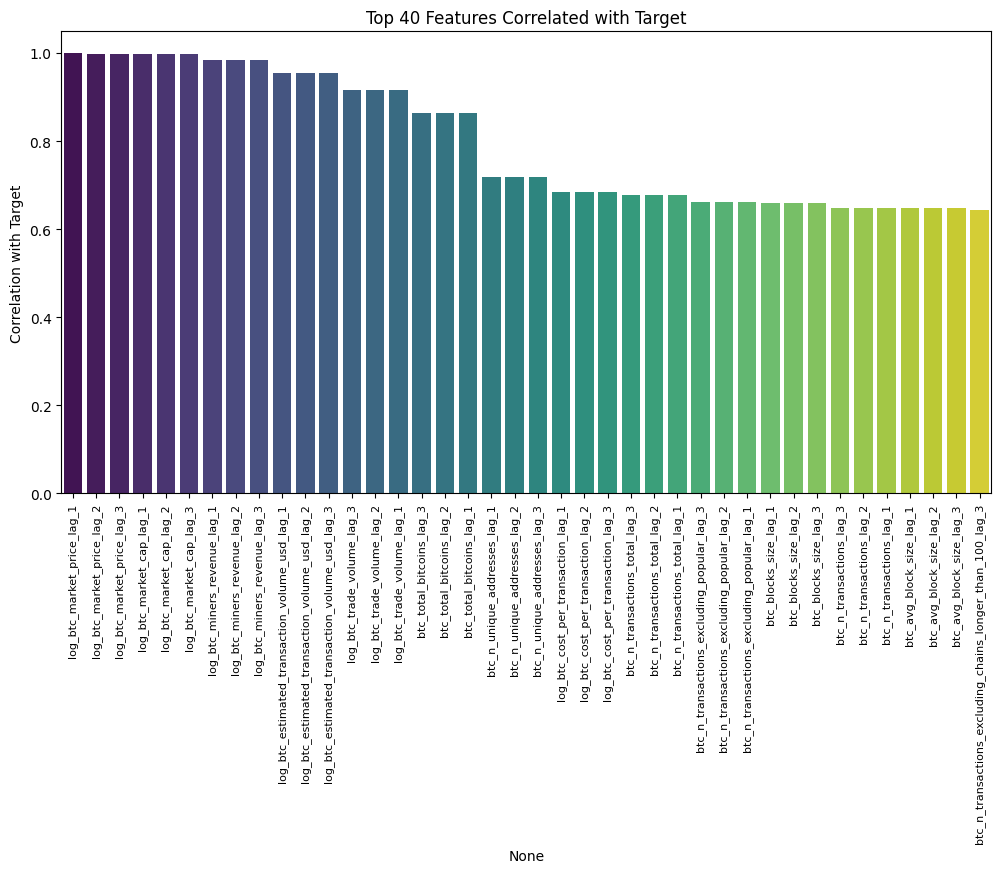

In [20]:
# Combine X_train and y_train for correlation calculation
cor_target = X_train.copy()
cor_target['target'] = y_train

correlations = cor_target.corr()['target'].sort_values(ascending=False)

# Plot top 20 features correlated with the target
top_features = correlations[1:41]  # skip 'target' itself

plt.figure(figsize=(12,6))
sns.barplot(x=top_features.index, y=top_features.values, palette='viridis')
plt.xticks(rotation=90)
plt.xticks(fontsize=8) 
plt.ylabel('Correlation with Target')
plt.title('Top 40 Features Correlated with Target')
plt.show()


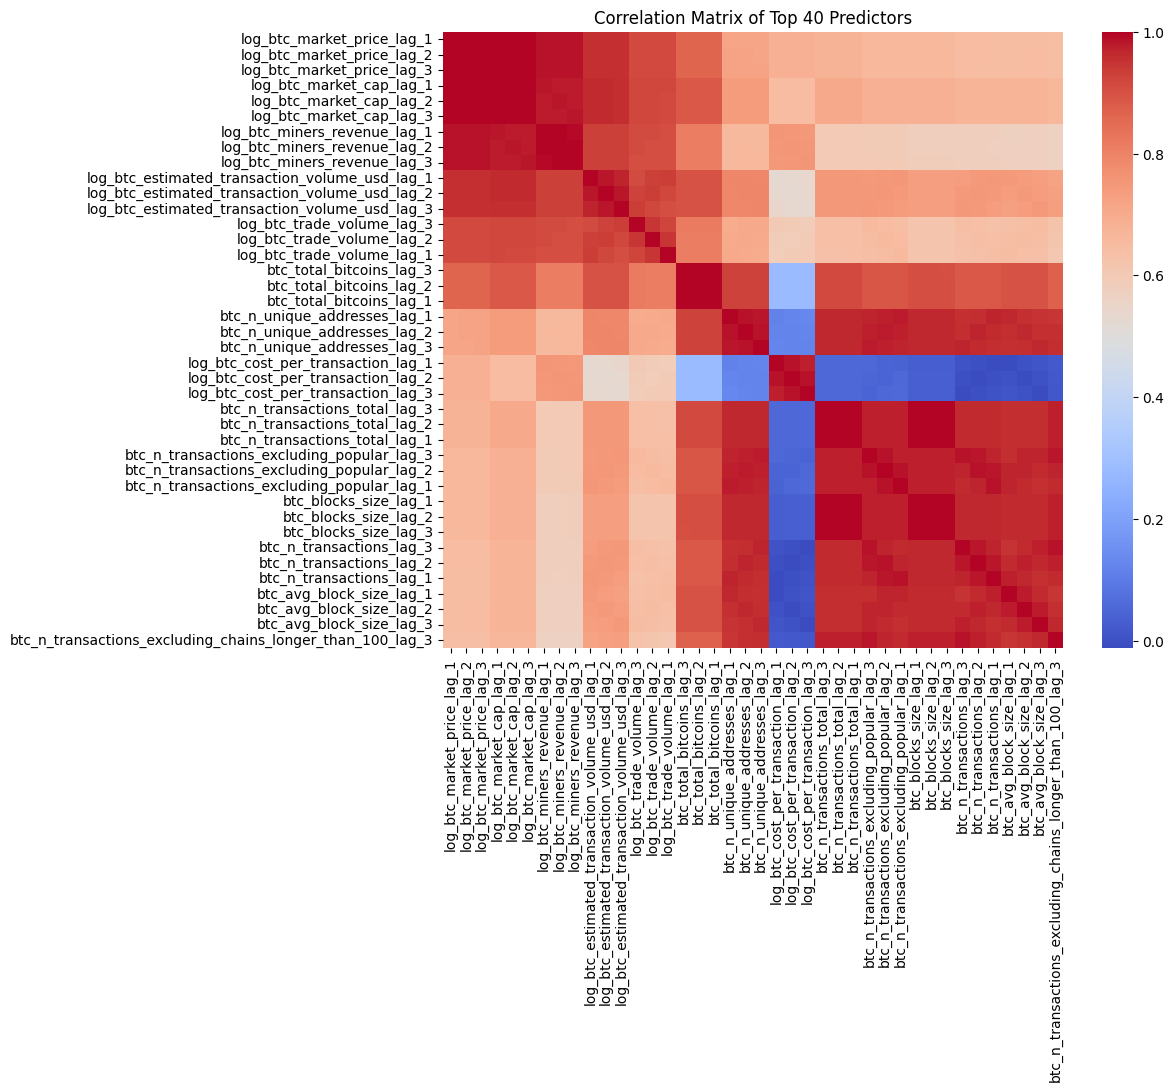

In [21]:
top_corr_features = top_features.index.tolist()
top_corr_matrix = X_train[top_corr_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(top_corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Matrix of Top 40 Predictors')
plt.show()


## Fit baseline model - MLR using lag features

In [28]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train) 
y_test_pred = lr.predict(X_test)   

# Metrics
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Train R^2:", r2_score(y_train, y_train_pred))
print("Test R^2:", r2_score(y_test, y_test_pred))

Train MSE: 0.00443323183573425
Test MSE: 0.23224698555480575
Train R^2: 0.9983647741365235
Test R^2: 0.7495420501633486


## Standardize features

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## lasso Regresion 

In [34]:
alphas = [0.1, 1, 10, 100]

for alpha in alphas:
    print("alpha:", alpha)
    ridge = Ridge(alpha=alpha)  
    ridge.fit(X_train_scaled, y_train)

    y_train_ridge = ridge.predict(X_train_scaled)
    y_test_ridge = ridge.predict(X_test_scaled)

    print("\tTrain MSE:", mean_squared_error(y_train, y_train_ridge))
    print("\tTest MSE:", mean_squared_error(y_test, y_test_ridge))
    print("\tTrain R^2:", r2_score(y_train, y_train_ridge))
    print("\tTest R^2:", r2_score(y_test, y_test_ridge))


alpha: 0.1
	Train MSE: 0.004117744786082611
	Test MSE: 0.06650326231947279
	Train R^2: 0.9984811435487937
	Test R^2: 0.9282820799667446
alpha: 1
	Train MSE: 0.004325230034354991
	Test MSE: 0.04823063471342344
	Train R^2: 0.9984046112904241
	Test R^2: 0.9479875019226294
alpha: 10
	Train MSE: 0.005082296836941369
	Test MSE: 0.008136091518939383
	Train R^2: 0.998125362367327
	Test R^2: 0.9912259407946715
alpha: 100
	Train MSE: 0.008896718607113288
	Test MSE: 0.2137762493749843
	Train R^2: 0.9967183885468928
	Test R^2: 0.7694611147941361


## Lasso Regression

In [37]:
alphas = [0.01, 0.1, 1, 10, 100]

for alpha in alphas:
    print("alpha:", alpha)
    lasso = Lasso(alpha=alpha)  
    lasso.fit(X_train_scaled, y_train)

    y_train_lasso = lasso.predict(X_train_scaled)
    y_test_lasso= lasso.predict(X_test_scaled)

    print("\tTrain MSE:", mean_squared_error(y_train, y_train_lasso))
    print("\tTest MSE:", mean_squared_error(y_test, y_test_lasso))
    print("\tTrain R^2:", r2_score(y_train, y_train_lasso))
    print("\tTest R^2:", r2_score(y_test, y_test_lasso))


alpha: 0.01
	Train MSE: 0.004462401709469768
	Test MSE: 0.005973466472324368
	Train R^2: 0.9983540146423814
	Test R^2: 0.993558141723552
alpha: 0.1
	Train MSE: 0.01438842515399387
	Test MSE: 0.047956705569533874
	Train R^2: 0.9946927375291189
	Test R^2: 0.94828291041465
alpha: 1
	Train MSE: 1.0043906124776554
	Test MSE: 3.800743001509016
	Train R^2: 0.6295241107586863
	Test R^2: -3.0987670851353766
alpha: 10
	Train MSE: 2.7110822637729983
	Test MSE: 10.221285822959782
	Train R^2: 0.0
	Test R^2: -10.02275788767483
alpha: 100
	Train MSE: 2.7110822637729983
	Test MSE: 10.221285822959782
	Train R^2: 0.0
	Test R^2: -10.02275788767483


## Model Comparison Results

| Model        | Alpha | Train MSE       | Test MSE        | Train R²       | Test R²       |
|-------------|-------|----------------|----------------|----------------|---------------|
| MLR         | -     | 0.004433       | 0.232247       | 0.998365       | 0.749542      |
| Ridge       | 0.1   | 0.004118       | 0.066503       | 0.998481       | 0.928282      |
| Ridge       | 1     | 0.004325       | 0.048231       | 0.998405       | 0.947988      |
| Ridge       | 10    | 0.005082       | 0.008136       | 0.998125       | 0.991226      |
| Ridge       | 100   | 0.008897       | 0.213776       | 0.996718       | 0.769461      |
| Lasso       | 0.01  | 0.004462       | 0.005973       | 0.998354       | 0.993558      |
| Lasso       | 0.1   | 0.014388       | 0.047957       | 0.994693       | 0.948283      |
| Lasso       | 1     | 1.004391       | 3.800743       | 0.629524       | -3.098767     |
| Lasso       | 10    | 2.711082       | 10.221286      | 0.000000       | -10.022758    |
| Lasso       | 100   | 2.711082       | 10.221286      | 0.000000       | -10.022758    |


### Observations: 

1. MLR baseline
    - Very high train R² (~0.998) but lower test R² (~0.75) → some overfitting.

2. Ridge
    - alpha=10 gives best test R² (~0.991) → good trade-off between bias and variance.

3. Lasso
    - Small alpha=0.01 works well (test R² ~0.994), larger alphas quickly degrade performance.

 ## Plot Best Lasso and Ridge Models

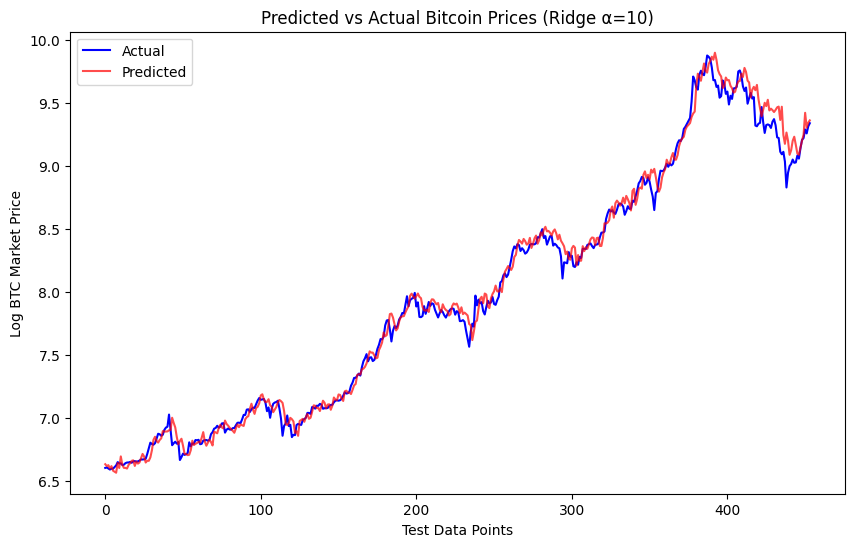

In [39]:
# Predictions using Ridge alpha=10
ridge_best = Ridge(alpha=10)
ridge_best.fit(X_train_scaled, y_train)
y_test_pred_ridge = ridge_best.predict(X_test_scaled)

# Plot predicted vs actual
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_test_pred_ridge, label='Predicted', color='red', alpha=0.7)
plt.xlabel('Test Data Points')
plt.ylabel('Log BTC Market Price')
plt.title('Predicted vs Actual Bitcoin Prices (Ridge α=10)')
plt.legend()
plt.show()


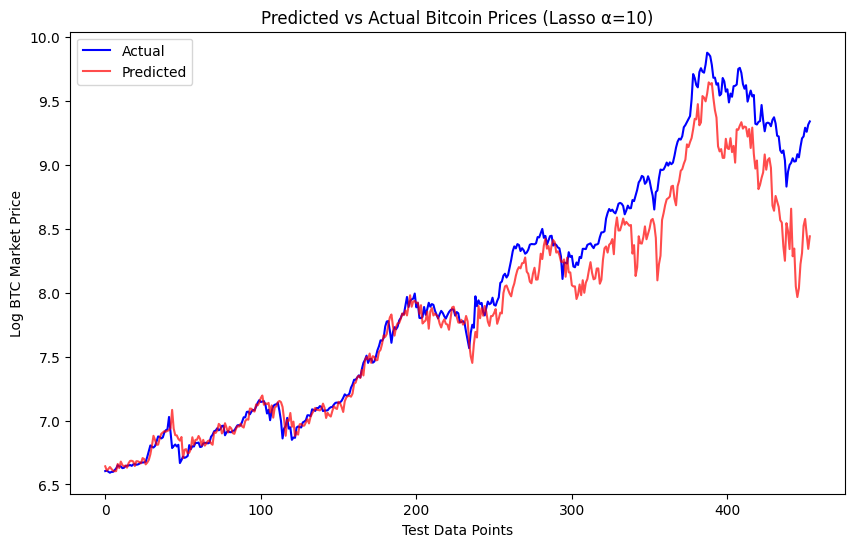

In [40]:
# Predictions using Lasso alpha=0.1
lasso_best = Ridge(alpha=0.01)
lasso_best.fit(X_train_scaled, y_train)
y_test_pred_ridge = lasso_best.predict(X_test_scaled)

# Plot predicted vs actual
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_test_pred_ridge, label='Predicted', color='red', alpha=0.7)
plt.xlabel('Test Data Points')
plt.ylabel('Log BTC Market Price')
plt.title('Predicted vs Actual Bitcoin Prices (Lasso α=10)')
plt.legend()
plt.show()

Ridge with α=10 looks like the best model! Let's look at residuals...

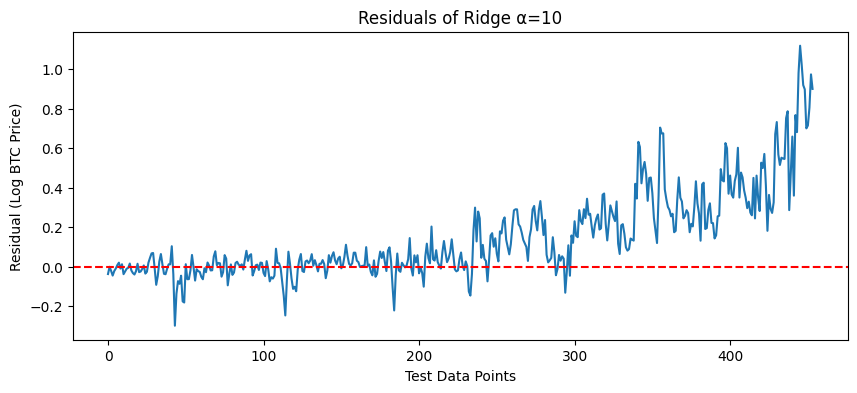

In [42]:
residuals = y_test['target'] - y_test_pred_ridge
plt.figure(figsize=(10,4))
plt.plot(residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Test Data Points')
plt.ylabel('Residual (Log BTC Price)')
plt.title('Residuals of Ridge α=10')
plt.show()


This plot suggests pattern is not completely random; the residuals show a slight upward trend toward the end, which can indicate heteroscedasticity or some nonlinearity that Ridge cannot fully capture.